# DNA Splice Junction Classification
## DNA-Specific Exploratory Data Analysis

In the previous notebooks, I understood and cleaned the dataset.

Now I will explore the DNA sequences themselves. Since DNA is sequential data, I will focus on nucleotide composition and positional patterns across the three classes.

The purpose of this analysis is to identify useful patterns before converting the sequences into k-mer features.

## 1. Nucleotide Composition

### WHY

Different splice-junction classes may contain different nucleotide patterns.

I will first compare the overall nucleotide composition of the three classes.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw/splice.data")

cleaned_data = pd.read_csv(
    DATA_PATH,
    header=None,
    skipinitialspace=True
)

cleaned_data.columns = ["class", "instance_name", "sequence"]

cleaned_data = cleaned_data.drop_duplicates()

print("Cleaned dataset shape:", cleaned_data.shape)

Cleaned dataset shape: (3178, 3)


In [3]:
nucleotides = ["A", "C", "D", "G", "N", "R", "S", "T"]

class_composition = {}

for label in sorted(cleaned_data["class"].unique()):
    sequences = cleaned_data.loc[cleaned_data["class"] == label, "sequence"]
    counts = pd.Series(list("".join(sequences))).value_counts()
    class_composition[label] = counts

composition_df = pd.DataFrame(class_composition).fillna(0)

composition_df

,EI,IE,N
A,10107.0,9385.0,24810.0
C,11224.0,14019.0,24902.0
D,0.0,1.0,1.0
G,14350.0,10233.0,25474.0
N,46.0,0.0,10.0
R,0.0,1.0,0.0
S,0.0,1.0,0.0
T,9933.0,12080.0,24103.0


In [4]:
composition_percentage = composition_df.div(
    composition_df.sum(axis=0),
    axis=1
).mul(100).round(2)

composition_percentage

,EI,IE,N
A,22.14,20.53,24.98
C,24.58,30.66,25.08
D,0.00,0.00,0.00
G,31.43,22.38,25.65
N,0.10,0.00,0.01
R,0.00,0.00,0.00
S,0.00,0.00,0.00
T,21.75,26.42,24.27


### FIND

The nucleotide composition varies across the three classes.

The four standard nucleotides account for most of the sequence characters, while the ambiguity symbols occur less frequently.

The class-wise composition provides an initial indication that the sequence content may differ between splice-junction categories.

<Figure size 1000x500 with 0 Axes>

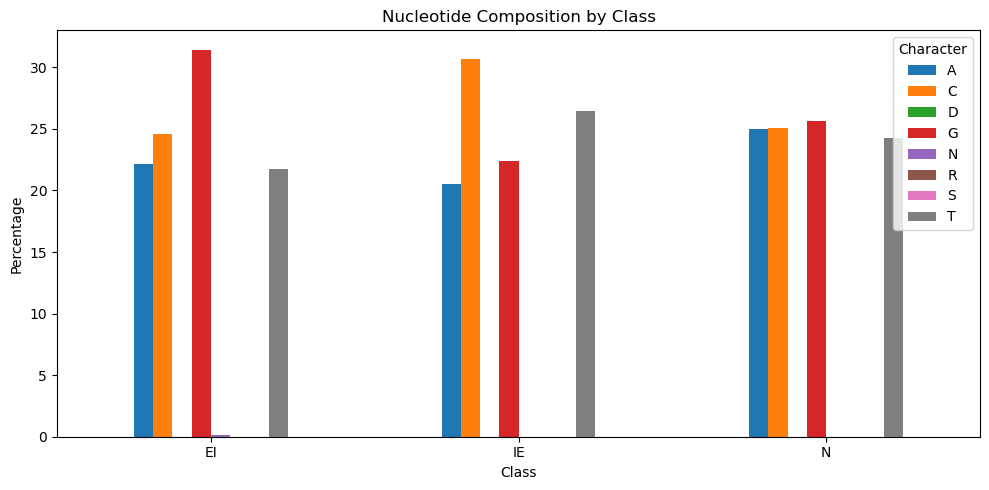

In [6]:
plt.figure(figsize=(10, 5))

composition_percentage.T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Class")
plt.ylabel("Percentage")
plt.title("Nucleotide Composition by Class")
plt.xticks(rotation=0)
plt.legend(title="Character")
plt.tight_layout()

plt.savefig(
    "../reports/figures/nucleotide_composition_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### DECIDE

Nucleotide composition is useful for understanding broad differences between classes, but it does not capture the order of nucleotides.

Because splice-junction patterns depend on sequence context, I will investigate positional patterns next.

## 2. Position-wise Nucleotide Distribution

### WHY

Every sequence contains exactly 60 positions.

A nucleotide may be more common at particular positions around a splice junction.

I will therefore examine nucleotide frequencies across sequence positions.

In [7]:
position_counts = {}

for position in range(60):
    position_counts[position + 1] = (
        cleaned_data["sequence"]
        .str[position]
        .value_counts()
    )

position_counts_df = pd.DataFrame(position_counts).fillna(0)

position_counts_df.head()

,1,2,3,4,5,6,7,8,9,10,...,51,52,53,54,55,56,57,58,59,60
sequence,,,,,,,,,,,,,,,,,,,,,
A,736.0,776.0,711.0,749.0,799.0,701.0,779.0,786.0,747.0,762.0,...,693.0,813.0,731.0,692.0,799.0,751.0,739.0,716.0,783.0,718.0
C,834.0,857.0,874.0,879.0,861.0,897.0,856.0,872.0,904.0,808.0,...,878.0,785.0,827.0,815.0,834.0,829.0,789.0,869.0,858.0,781.0
D,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,875.0,791.0,835.0,799.0,718.0,824.0,778.0,730.0,747.0,763.0,...,897.0,874.0,871.0,931.0,856.0,835.0,902.0,863.0,784.0,949.0
N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0


In [8]:
position_percentages = position_counts_df.div(
    position_counts_df.sum(axis=0),
    axis=1
).mul(100)

position_percentages.head()

,1,2,3,4,5,6,7,8,9,10,...,51,52,53,54,55,56,57,58,59,60
sequence,,,,,,,,,,,,,,,,,,,,,
A,23.159220,24.417873,22.372561,23.568282,25.141598,22.057898,24.512272,24.732536,23.505349,23.977344,...,21.806167,25.582127,23.001888,21.774701,25.141598,23.631215,23.253619,22.529893,24.638137,22.592826
C,26.242920,26.966646,27.501573,27.658905,27.092511,28.225299,26.935179,27.438641,28.445563,25.424795,...,27.627439,24.701070,26.022656,25.645060,26.242920,26.085588,24.826935,27.344242,26.998112,24.575205
D,0.031466,0.031466,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
G,27.533040,24.889868,26.274386,25.141598,22.592826,25.928257,24.480806,22.970422,23.505349,24.008811,...,28.225299,27.501573,27.407174,29.295154,26.935179,26.274386,28.382631,27.155444,24.669604,29.861548
N,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.031466,0.031466,0.031466,0.031466,0.031466,0.062933,0.031466,0.031466,0.031466,0.031466


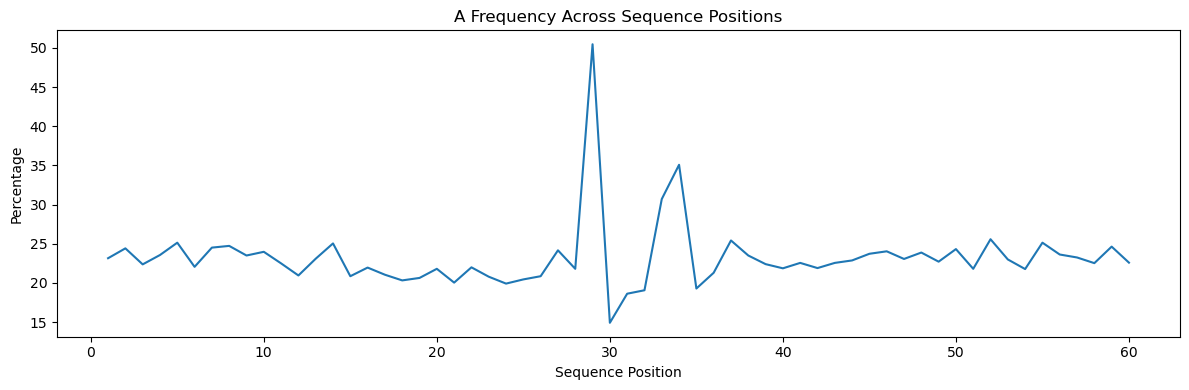

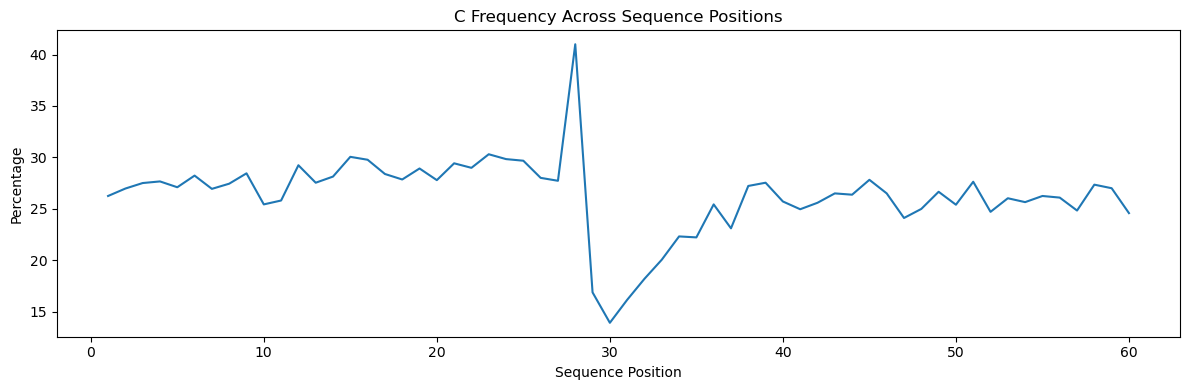

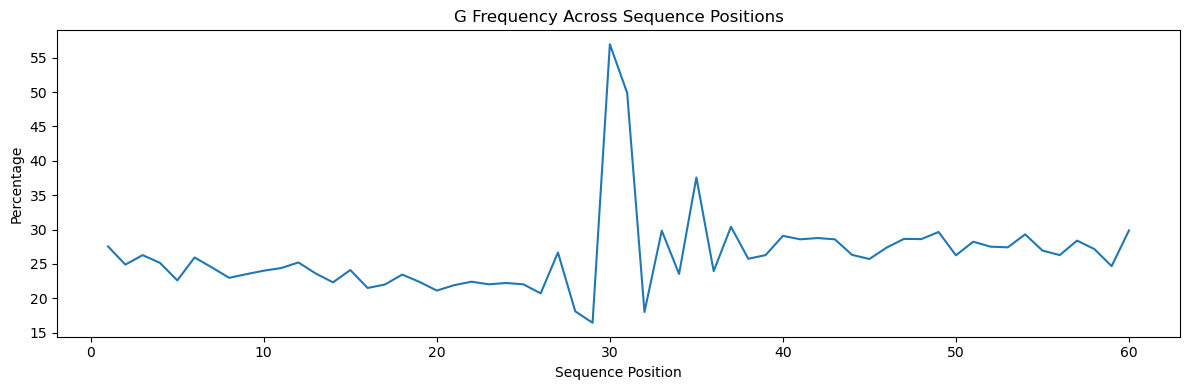

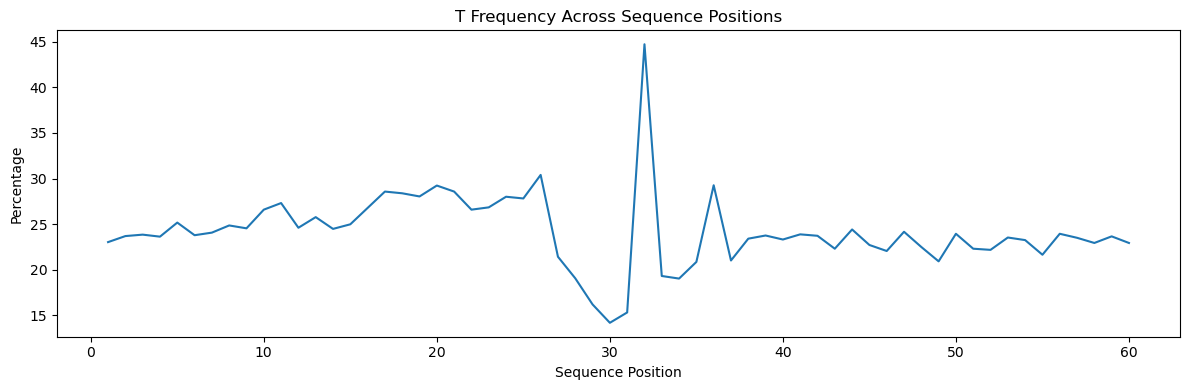

In [10]:
standard_bases = ["A", "C", "G", "T"]

for base in standard_bases:
    plt.figure(figsize=(12, 4))

    plt.plot(
        position_percentages.columns,
        position_percentages.loc[base]
    )

    plt.xlabel("Sequence Position")
    plt.ylabel("Percentage")
    plt.title(f"{base} Frequency Across Sequence Positions")

    plt.tight_layout()

    plt.savefig(
        f"../reports/figures/{base.lower()}_frequency_by_position.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

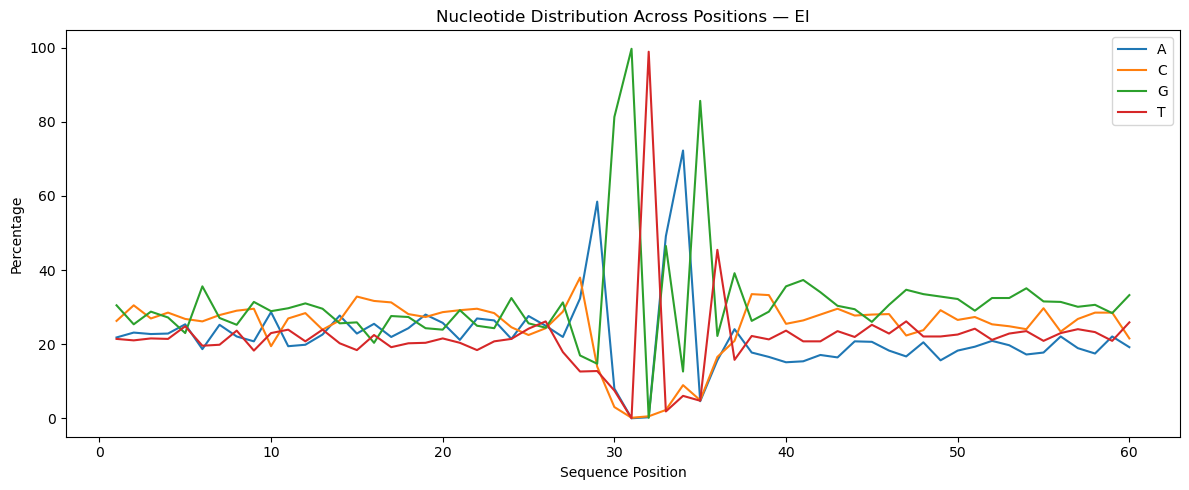

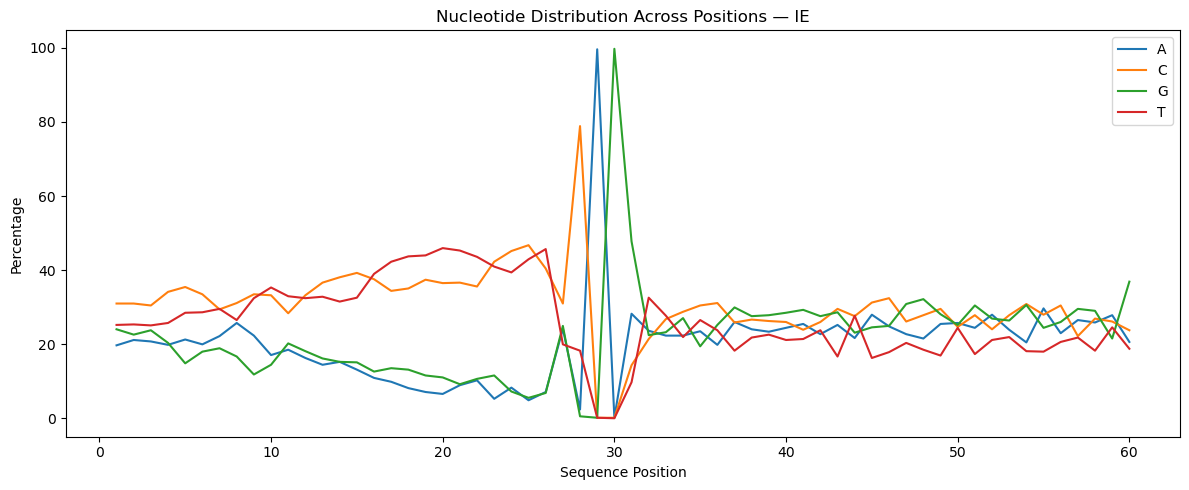

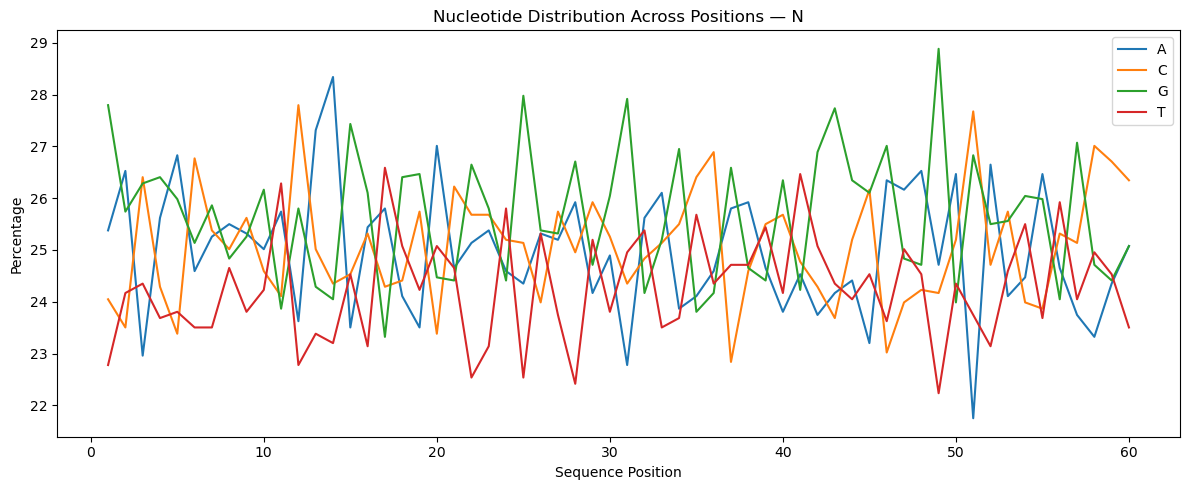

In [12]:
for label in sorted(cleaned_data["class"].unique()):
    class_data = cleaned_data[cleaned_data["class"] == label]

    class_position_counts = pd.DataFrame({
        position + 1: class_data["sequence"].str[position].value_counts()
        for position in range(60)
    }).fillna(0)

    class_position_percentages = class_position_counts.div(
        class_position_counts.sum(axis=0),
        axis=1
    ).mul(100)

    plt.figure(figsize=(12, 5))

    for base in standard_bases:
        plt.plot(
            class_position_percentages.columns,
            class_position_percentages.loc[base]
        )

    plt.xlabel("Sequence Position")
    plt.ylabel("Percentage")
    plt.title(f"Nucleotide Distribution Across Positions — {label}")
    plt.legend(standard_bases)
    plt.tight_layout()

    plt.savefig(
        f"../reports/figures/position_distribution_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### FIND

The positional nucleotide distributions are not completely uniform across the 60 positions.

The patterns also differ between the `EI`, `IE`, and `N` classes.

This suggests that sequence position and local nucleotide context may contain information useful for classification.

In [13]:
ambiguity_codes = ["D", "N", "R", "S"]

ambiguity_counts = cleaned_data["sequence"].apply(
    lambda sequence: sum(character in ambiguity_codes for character in sequence)
)

ambiguity_counts.describe()

count    3178.000000
mean        0.018880
std         0.733837
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        41.000000
Name: sequence, dtype: float64

In [14]:
ambiguity_by_class = (
    cleaned_data.assign(ambiguity_count=ambiguity_counts)
    .groupby("class")["ambiguity_count"]
    .mean()
    .round(2)
)

ambiguity_by_class

class
EI    0.06
IE    0.00
N     0.01
Name: ambiguity_count, dtype: float64

### FIND

Ambiguity symbols are present in the dataset but occur less frequently than the standard nucleotide symbols.

Their presence is part of the original biological representation and should not be treated as invalid data.

### DECIDE

I will preserve the ambiguity symbols during feature engineering.

The k-mer representation will therefore be generated from the sequences as they are represented in the cleaned dataset.

## 3. EDA Findings

### FIND

The DNA-specific analysis shows that:

- Nucleotide composition differs across the three classes.
- Nucleotide frequencies vary across sequence positions.
- Positional patterns differ between `EI`, `IE`, and `N`.
- Ambiguity symbols occur in the original sequences and are valid parts of the dataset.
- Sequence order appears important, so overall nucleotide counts alone may not be sufficient to represent the sequences.

### DECIDE

The exploratory analysis supports using a feature representation that captures local sequence patterns rather than relying only on overall nucleotide frequencies.

For this project, I will use k-mers to represent these local sequence patterns.

The actual k-mer feature engineering will be performed in the next notebook.